In [8]:
"""Pull Daymet data for each well site in the northeastern US."""
# 
import pandas as pd
import geopandas as gpd
import requests
from io import StringIO
import matplotlib.pyplot as plt
import os


In [9]:
#Load in files and assign names
well_sites = r"C:\Users\romin\OneDrive\Groundwater\RpSy Data\Site information for all selected wells.xlsx"
station_sites = r"C:\Users\romin\OneDrive\Groundwater\ghcnd-stations.txt"
state_boundaries = r"C:\Users\romin\OneDrive\Groundwater\cb_2022_us_state_500k"  
# 
NE_states = [
    "Connecticut", "Maine", "Massachusetts", "New Hampshire",
    "Rhode Island", "Vermont", "New Jersey", "New York", "Pennsylvania",
]
#Assign the standardized two lettter code for each state
NE_codes = ["CT", "ME", "MA", "NH", "RI", "VT", "NJ", "NY", "PA"]
out_dir = "outputs"
# 

In [10]:
def load_sites(path=well_sites):
    df = pd.read_excel(path)
    df = df.rename(columns={
        "ID": "usgs_id",
        "Lat": "lat",
        "Long": "lon",
        "depth (m)": "depth",
    })
    return df
#Isolate the northeastern wells
def select_ne_wells(df_sites, states_shp=state_boundaries):
    states = gpd.read_file(states_shp)
    ne = states[states["NAME"].isin(NE_states)].set_crs(epsg=4326, allow_override=True)
    gdf_sites = gpd.GeoDataFrame(
        df_sites,
        geometry=gpd.points_from_xy(df_sites["lon"], df_sites["lat"]),
        crs="EPSG:4326",
    )
    joined = gpd.sjoin(gdf_sites, ne[["NAME", "geometry"]], how="inner", predicate="within")
    joined = joined.rename(columns={"NAME": "state"}).drop(columns=["index_right"])
    return joined # 
df_sites = load_sites()
df_ne_wells = select_ne_wells(df_sites)
df_ne_wells

,usgs_id,lat,lon,depth,geometry,state
211,390211074505502,39.036502,-74.848224,7.9248,POINT (-74.84822 39.0365),New Jersey
217,391145074520401,39.195948,-74.867392,3.3528,POINT (-74.86739 39.19595),New Jersey
220,391621074435401,39.272615,-74.731274,6.8580,POINT (-74.73127 39.27261),New Jersey
225,392232074234403,39.395672,-74.625158,21.6408,POINT (-74.62516 39.39567),New Jersey
228,392731075092401,39.459004,-75.157683,14.3256,POINT (-75.15768 39.459),New Jersey
...,...,...,...,...,...,...
460,445052073350201,44.848000,-73.584000,23.7744,POINT (-73.584 44.848),New York
461,445227067520101,44.874240,-67.866392,9.1440,POINT (-67.86639 44.87424),Maine
462,445511074103901,44.919740,-74.177176,11.2776,POINT (-74.17718 44.91974),New York
463,445805073380501,44.968083,-73.634694,1.8288,POINT (-73.63469 44.96808),New York


Text(0, 0.5, 'Record Length (years)')

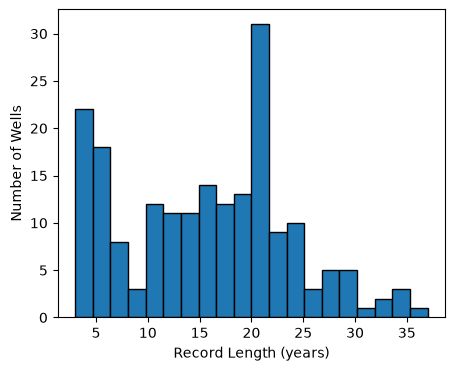

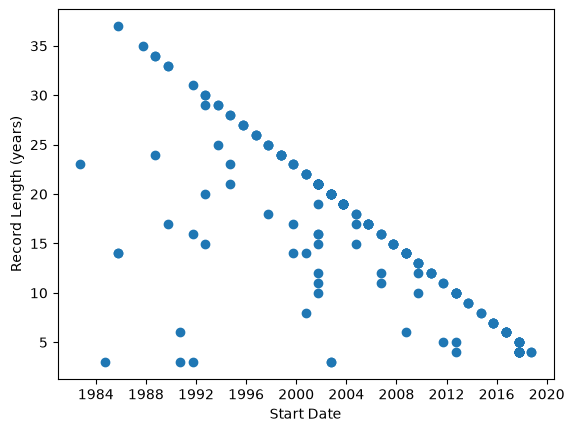

In [11]:
#  get start and end dates for each well site based on the available data
def get_start_end_dates(df, date_col="Date"):
    df[date_col] = pd.to_datetime(df[date_col])
    start_date = df[date_col].min()
    end_date = df[date_col].max()
    return start_date, end_date
start_dates = []
end_dates = []
for id in df_ne_wells["usgs_id"]:
    df = pd.read_csv(f"C:/Users/romin/OneDrive/Groundwater/RpSy Data/{id}.csv")
    start_date, end_date = get_start_end_dates(df)
    start_dates.append(start_date)
    end_dates.append(end_date)
df_ne_wells["start_date"] = start_dates
df_ne_wells["end_date"] = end_dates
#  plot record length histogram for northeastern wells
df_ne_wells["record_length"] = (df_ne_wells["end_date"] - df_ne_wells["start_date"]).dt.days / 365.25
plt.figure(figsize=(5, 4))
plt.hist(df_ne_wells["record_length"], bins=20, edgecolor="black")
plt.xlabel("Record Length (years)")
plt.ylabel("Number of Wells")
plt.figure()
plt.scatter(df_ne_wells['start_date'], df_ne_wells['record_length'])
plt.xlabel("Start Date")
plt.ylabel("Record Length (years)")

In [15]:
#   Write Daymet API URL (will use to pull data for each well site)
def write_daymet_api_url(lat, lon, vars, start_date, end_date):
    start_date = pd.to_datetime(start_date).strftime("%Y-%m-%d")
    end_date = pd.to_datetime(end_date).strftime("%Y-%m-%d")
    base_url = "https://daymet.ornl.gov/single-pixel/api/data"
    url = f"{base_url}?lat={lat}&lon={lon}&vars={vars}&start={start_date}&end={end_date}"
    return url

# test single url for first well site
url = write_daymet_api_url(df_ne_wells.iloc[0]["lat"], 
                     df_ne_wells.iloc[0]["lon"], 
                     "prcp,tmax,tmin,swe", 
                     df_ne_wells.iloc[0]["start_date"],
                     df_ne_wells.iloc[0]["end_date"])

if not os.path.exists("./daymet"):
    os.makedirs("./daymet")

for i, id in enumerate(df_ne_wells["usgs_id"]):
    out_path = f"./daymet/{id}.csv"
    if os.path.exists(out_path):
        print(f"[{i+1}/{len(df_ne_wells)}] {id} already downloaded, skipping.")
        continue

    print(f"[{i+1}/{len(df_ne_wells)}] Fetching well {id}...")
    df = pd.read_csv(f"C:/Users/romin/OneDrive/Groundwater/RpSy Data/{id}.csv")
    start_date, end_date = get_start_end_dates(df)
    lat = df_ne_wells[df_ne_wells["usgs_id"] == id]["lat"].values[0]
    lon = df_ne_wells[df_ne_wells["usgs_id"] == id]["lon"].values[0]
    url = write_daymet_api_url(lat, lon, "prcp,tmax,tmin,swe", start_date, end_date)

    request = requests.get(url, timeout=30)
    if request.status_code == 200:
        df_daymet = pd.read_csv(StringIO(request.text), sep=",", header=6)
        df_daymet.to_csv(out_path, index=False)
    else:
        print(f"  Failed (status {request.status_code})")

print("\nDone.")

[1/194] 390211074505502 already downloaded, skipping.
[2/194] 391145074520401 already downloaded, skipping.
[3/194] 391621074435401 already downloaded, skipping.
[4/194] 392232074234403 already downloaded, skipping.
[5/194] 392731075092401 already downloaded, skipping.
[6/194] 392732075092401 already downloaded, skipping.
[7/194] 392920074570001 already downloaded, skipping.
[8/194] 393232074263903 already downloaded, skipping.
[9/194] 393246075012701 already downloaded, skipping.
[10/194] 393749074550901 already downloaded, skipping.
[11/194] 394106074362501 already downloaded, skipping.
[12/194] 394236075272101 already downloaded, skipping.
[13/194] 394354075025901 already downloaded, skipping.
[14/194] 394422074430903 already downloaded, skipping.
[15/194] 394430077225001 already downloaded, skipping.
[16/194] 394440074593101 already downloaded, skipping.
[17/194] 394452074281901 already downloaded, skipping.
[18/194] 394742074142002 already downloaded, skipping.
[19/194] 3950340741